# 06 — Predicción de no-shows en reservas

**Objetivo:** predecir la probabilidad de que una reserva individual
termine en no-show, usando el histórico completo de reservas (Silver),
no solo el período con datos de ventas.

**Momento de predicción:** el día del servicio (overbooking operativo a
corto plazo). Esto determina qué variables son legítimas como feature y
cuáles constituyen leakage — ver auditoría en la Sección de feature
engineering.

**Universo de modelado:** reservas con desenlace resuelto sin ambigüedad
(`completada`, `no_show`), desde 2023-01-01, excluyendo el canal walk-in
(0 no-shows observados en ese canal — ver justificación cuantitativa más
abajo).

*Arquitectura Medallion: Bronze → Silver → **Gold***

### 0. Setup

Imports, rutas, carga de reservas (Silver, nivel individual) y de la
tabla maestra diaria (Gold, para variables de contexto del día de
servicio: meteorología, festivos, eventos).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR    = DATA_DIR / 'gold'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'noshows'
MODELS_DIR  = PROJECT_ROOT / 'results' / 'models'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Silver snaps : {SILVER_SNAP}')
print(f'Gold dir     : {GOLD_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')
print(f'Models dir   : {MODELS_DIR}')

Project root : /Users/laura/TFM-Hosteleria-AI
Silver snaps : /Users/laura/TFM-Hosteleria-AI/data/silver/snapshots
Gold dir     : /Users/laura/TFM-Hosteleria-AI/data/gold
Figures dir  : /Users/laura/TFM-Hosteleria-AI/results/figures/noshows
Models dir   : /Users/laura/TFM-Hosteleria-AI/results/models


In [2]:
# Reservas a nivel individual (Silver) — fuente principal del modelo.
# Ya incluye status_agrupado (5 categorías) y antelacion_horas persistida,
# ambas decididas y aplicadas en 02_depuracion_silver.
df_reservas = pd.read_parquet(SILVER_SNAP / 'reservas_silver.parquet')

# Tabla maestra diaria (Gold) — se usará más adelante para variables de
# contexto del día de servicio (meteo, festivo, evento), no para el
# universo de modelado en sí, que es a nivel de reserva individual, no
# de día agregado.
tabla_maestra_diaria = pd.read_parquet(GOLD_DIR / 'tabla_maestra_diaria.parquet')

print(f'Reservas (Silver)        : {df_reservas.shape}')
print(f'  Rango temporal         : {df_reservas["reservation_date"].min().date()} → '
      f'{df_reservas["reservation_date"].max().date()}')
print(f'  Columnas                : {df_reservas.columns.tolist()}')
print()
print(f'Tabla maestra diaria (Gold): {tabla_maestra_diaria.shape}')
print(f'  Rango temporal           : {tabla_maestra_diaria["fecha"].min().date()} → '
      f'{tabla_maestra_diaria["fecha"].max().date()}')

# Verificación de sanidad: confirmar que las columnas clave de la
# reclasificación de Silver están presentes antes de seguir.
assert 'status_agrupado' in df_reservas.columns, "Falta status_agrupado — revisa Silver"
assert 'antelacion_horas' in df_reservas.columns, "Falta antelacion_horas — revisa Silver"
assert set(df_reservas['status_agrupado'].unique()) == {
    'completada', 'cancelada', 'no_show', 'pendiente', 'liberada'
}, "Categorías de status_agrupado inesperadas — revisa si Silver se regeneró correctamente"

print("\n✓ Silver cargado con las 5 categorías esperadas y antelacion_horas presente")

Reservas (Silver)        : (21289, 21)
  Rango temporal         : 2022-11-10 → 2026-07-08
  Columnas                : ['source_file', 'reservation_datetime', 'created_datetime', 'reservation_date', 'reservation_time', 'status', 'shift', 'people', 'origin', 'created_date', 'created_time', 'restaurant', 'reservation_type', 'table', 'zone', 'group', 'reference_code', 'status_agrupado', 'es_walk_in', 'es_grupo_grande', 'antelacion_horas']

Tabla maestra diaria (Gold): (242, 37)
  Rango temporal           : 2025-10-02 → 2026-07-09

✓ Silver cargado con las 5 categorías esperadas y antelacion_horas presente


### 1. Definición del universo de modelado

Se aplican tres filtros secuenciales sobre `df_reservas`, cada uno con
conteo explícito de filas incluidas/excluidas y su motivo:

1. **Desenlace resuelto sin ambigüedad**: `status_agrupado ∈ {completada, no_show}`.
   Se excluyen `cancelada` (desenlace distinto al que modela este target),
   `pendiente` (desenlace aún no conocido) y `liberada` (desenlace
   ambiguo, ver justificación en `02_depuracion_silver`).
2. **Corte temporal**: `reservation_date >= 2023-01-01`. Se excluye 2022
   por ser un año parcial de bajo volumen (721 filas de 21.289, ~3.4%).
3. **Exclusión de walk-in**: `origin != 'walk in'`. Justificación
   cuantitativa: dentro de walk-in, la tasa de no-show observada es 0%
   (verificado más abajo con los datos ya corregidos de Silver, no
   asumido del análisis exploratorio previo).

In [3]:
n_inicial = len(df_reservas)
print(f"Reservas totales en Silver: {n_inicial}\n")

# ── Filtro 1: desenlace resuelto sin ambigüedad ─────────────────────────
conteo_status = df_reservas['status_agrupado'].value_counts()
print("Distribución completa por status_agrupado:")
print(conteo_status.to_string())
print()

universo = df_reservas[df_reservas['status_agrupado'].isin(['completada', 'no_show'])].copy()
n_tras_filtro1 = len(universo)
print(f"Filtro 1 (completada + no_show): {n_tras_filtro1} filas "
      f"({n_inicial - n_tras_filtro1} excluidas)")
print(f"  - cancelada excluidas : {conteo_status.get('cancelada', 0)}")
print(f"  - pendiente excluidas : {conteo_status.get('pendiente', 0)}")
print(f"  - liberada excluidas  : {conteo_status.get('liberada', 0)}")
print()

# ── Filtro 2: corte temporal ─────────────────────────────────────────────
FECHA_INICIO_MODELO = pd.Timestamp('2023-01-01')
n_2022 = (universo['reservation_date'] < FECHA_INICIO_MODELO).sum()

universo = universo[universo['reservation_date'] >= FECHA_INICIO_MODELO].copy()
n_tras_filtro2 = len(universo)
print(f"Filtro 2 (desde {FECHA_INICIO_MODELO.date()}): {n_tras_filtro2} filas "
      f"({n_2022} excluidas, año 2022 parcial)")
print()

# ── Verificación cuantitativa antes del filtro 3: tasa de no-show en walk-in ──
tasa_noshow_walkin = (
    universo[universo['origin'] == 'walk in']['status_agrupado']
    .eq('no_show')
    .mean()
)
n_walkin = (universo['origin'] == 'walk in').sum()
print(f"Tasa de no-show dentro de walk-in: {tasa_noshow_walkin:.4f} "
      f"(sobre {n_walkin} reservas walk-in en el universo tras filtros 1-2)")

if tasa_noshow_walkin > 0:
    print("⚠️  ALERTA: hay no-shows dentro de walk-in — revisar antes de excluir el canal, "
          "la justificación cuantitativa ya no se sostiene tal cual.")
print()

# ── Filtro 3: exclusión de walk-in ───────────────────────────────────────
n_walkin_excluidas = (universo['origin'] == 'walk in').sum()

universo = universo[universo['origin'] != 'walk in'].copy()
n_tras_filtro3 = len(universo)
print(f"Filtro 3 (excluir walk-in): {n_tras_filtro3} filas "
      f"({n_walkin_excluidas} excluidas)")
print()

# ── Resumen del embudo completo ──────────────────────────────────────────
print("="*60)
print("RESUMEN DEL EMBUDO DE FILTRADO")
print("="*60)
print(f"{'Reservas totales (Silver)':<45} {n_inicial:>8}")
print(f"{'Tras filtro 1 (desenlace resuelto)':<45} {n_tras_filtro1:>8}")
print(f"{'Tras filtro 2 (desde 2023-01-01)':<45} {n_tras_filtro2:>8}")
print(f"{'Tras filtro 3 (sin walk-in)':<45} {n_tras_filtro3:>8}")
print(f"{'% del total original':<45} {n_tras_filtro3/n_inicial*100:>7.1f}%")

Reservas totales en Silver: 21289

Distribución completa por status_agrupado:
status_agrupado
completada    17243
cancelada      2886
liberada        662
no_show         493
pendiente         5

Filtro 1 (completada + no_show): 17736 filas (3553 excluidas)
  - cancelada excluidas : 2886
  - pendiente excluidas : 5
  - liberada excluidas  : 662

Filtro 2 (desde 2023-01-01): 17259 filas (477 excluidas, año 2022 parcial)

Tasa de no-show dentro de walk-in: 0.0000 (sobre 2840 reservas walk-in en el universo tras filtros 1-2)

Filtro 3 (excluir walk-in): 14419 filas (2840 excluidas)

RESUMEN DEL EMBUDO DE FILTRADO
Reservas totales (Silver)                        21289
Tras filtro 1 (desenlace resuelto)               17736
Tras filtro 2 (desde 2023-01-01)                 17259
Tras filtro 3 (sin walk-in)                      14419
% del total original                             67.7%


In [4]:
universo['es_no_show'] = (universo['status_agrupado'] == 'no_show').astype(int)

n_no_show = universo['es_no_show'].sum()
n_completada = len(universo) - n_no_show
tasa_base = universo['es_no_show'].mean()

print(f"Universo final de modelado: {len(universo)} reservas")
print(f"  - completada : {n_completada} ({(1-tasa_base)*100:.2f}%)")
print(f"  - no_show    : {n_no_show} ({tasa_base*100:.2f}%)")
print(f"\nTasa base de no-show: {tasa_base:.4f}")
print(f"Ratio de desbalance: 1 no-show por cada {n_completada/n_no_show:.1f} completadas")

Universo final de modelado: 14419 reservas
  - completada : 13945 (96.71%)
  - no_show    : 474 (3.29%)

Tasa base de no-show: 0.0329
Ratio de desbalance: 1 no-show por cada 29.4 completadas


### 2. Estabilidad temporal de la tasa de no-show

Antes de fijar el split cronológico, se comprueba si la tasa de no-show
se ha mantenido estable a lo largo del período de modelado (2023-01-01
en adelante) o si existe un cambio de régimen — igual que se detectó
para `Liberada` en la auditoría de Silver. Un cambio de régimen no
detectado podría hacer que un split 80/20 estándar entrene sobre un
patrón y evalúe sobre otro completamente distinto.

Evolución trimestral de la tasa de no-show:
         n_total  n_no_show  tasa_no_show
periodo                                  
2023Q1      1200         39          3.25
2023Q2      1085         29          2.67
2023Q3       804         38          4.73
2023Q4      1072         36          3.36
2024Q1      1077         25          2.32
2024Q2       982         38          3.87
2024Q3       719         32          4.45
2024Q4      1059         35          3.31
2025Q1      1137         27          2.37
2025Q2      1007         35          3.48
2025Q3       777         26          3.35
2025Q4      1087         45          4.14
2026Q1      1146         41          3.58
2026Q2      1184         28          2.36
2026Q3        83          0          0.00

Tasa global de referencia: 3.29%
Desviación estándar entre trimestres: 1.14 pp

⚠️  Trimestres con menos de 100 reservas (tasa poco fiable, no interpretar como cambio de régimen):
         n_total  n_no_show  tasa_no_show
periodo            

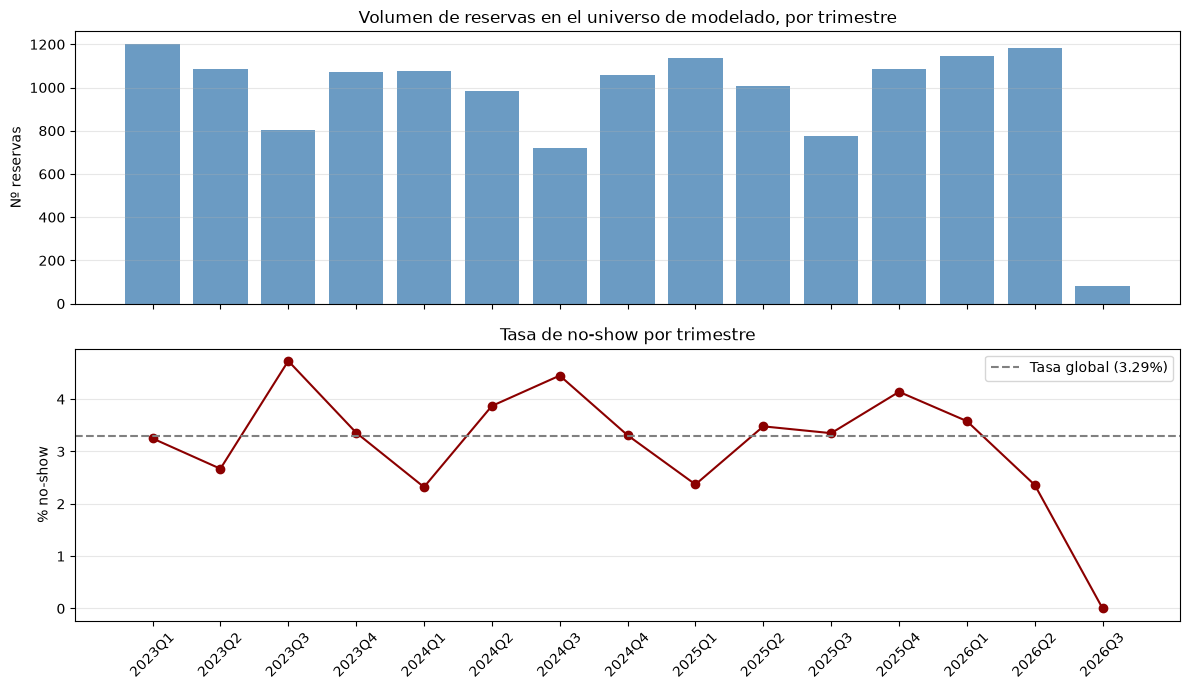

In [5]:
universo['periodo'] = universo['reservation_date'].dt.to_period('Q')

evolucion_noshow = (
    universo
    .groupby('periodo')
    .agg(
        n_total=('es_no_show', 'count'),
        n_no_show=('es_no_show', 'sum'),
    )
)
evolucion_noshow['tasa_no_show'] = (evolucion_noshow['n_no_show'] / evolucion_noshow['n_total'] * 100).round(2)

print("Evolución trimestral de la tasa de no-show:")
print(evolucion_noshow.to_string())
print()
print(f"Tasa global de referencia: {universo['es_no_show'].mean()*100:.2f}%")
print(f"Desviación estándar entre trimestres: {evolucion_noshow['tasa_no_show'].std():.2f} pp")

# Aviso si algún trimestre tiene muy pocos casos — la tasa en ese trimestre
# no es fiable aunque se aleje mucho de la media global
trimestres_pocos_casos = evolucion_noshow[evolucion_noshow['n_total'] < 100]
if len(trimestres_pocos_casos) > 0:
    print(f"\n⚠️  Trimestres con menos de 100 reservas (tasa poco fiable, no interpretar como cambio de régimen):")
    print(trimestres_pocos_casos.to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = evolucion_noshow.index.astype(str)

axes[0].bar(x, evolucion_noshow['n_total'], color='steelblue', alpha=0.8)
axes[0].set_title('Volumen de reservas en el universo de modelado, por trimestre')
axes[0].set_ylabel('Nº reservas')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(x, evolucion_noshow['tasa_no_show'], marker='o', color='darkred', linewidth=1.5)
axes[1].axhline(universo['es_no_show'].mean()*100, color='grey', linestyle='--',
                label=f'Tasa global ({universo["es_no_show"].mean()*100:.2f}%)')
axes[1].set_title('Tasa de no-show por trimestre')
axes[1].set_ylabel('% no-show')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'noshow_evolucion_trimestral.png', dpi=150, bbox_inches='tight')
plt.show()

universo = universo.drop(columns='periodo')

El split cronológico es seguro, no hay un punto de corte temporal donde el comportamiento de no-show cambie de naturaleza.

El 2026Q3 con 0.00% no es una señal, es un artefacto de fin de dataset. El histórico termina el 2026-07-08, así que ese trimestre solo tiene 8 días de julio (83 reservas - ningún no-show)

### 3. Selección de variables

Se construyen las features en tres bloques, siguiendo la auditoría de disponibilidad temporal ya cerrada (momento de predicción: día del servicio):

- **Bloque A**: atributos propios de la reserva individual.
- **Bloque B.1**: contexto de calendario y meteorología del día.
- **Bloque B.2**: contexto de eventos locales del día.

In [6]:
print("=== ZONE ===")
print(f"Nulos: {universo['zone'].isna().mean()*100:.2f}%")
print(f"Valores únicos: {universo['zone'].nunique()}")
print(universo['zone'].value_counts().head(10))
print()

print("=== GROUP ===")
print(f"Nulos: {universo['group'].isna().mean()*100:.2f}%")
print(f"Valores únicos: {universo['group'].nunique()}")
print(universo['group'].value_counts().head(10))
print()

# Verificación cruzada: ¿'zone' varía con 'shift' o es prácticamente fija?
# Si 'zone' rota por turno (ej. terraza solo en cena) puede ser información
# de calendario, no de asignación real de mesa.
print("Distribución de zone por shift (%):")
print(pd.crosstab(universo['shift'], universo['zone'], normalize='index').round(3) * 100)

=== ZONE ===
Nulos: 0.05%
Valores únicos: 2
zone
Sala                10265
Terraza Cubierta     4147
Name: count, dtype: int64

=== GROUP ===
Nulos: 0.00%
Valores únicos: 2
group
NO    14404
SI       15
Name: count, dtype: int64

Distribución de zone por shift (%):
zone    Sala  Terraza Cubierta
shift                         
Cena    70.6              29.4
Comida  71.8              28.2


`group` se excluye por dos motivos: (1) su significado no está documentado
en ningún punto del pipeline (Bronze/Silver), y (2) con solo 15 casos de
`SI` sobre 14.419 filas (0.1%), no hay volumen suficiente para que el
modelo aprenda un patrón fiable, incluso si el significado fuera relevante.

`table` se excluye por no poder verificarse su disponibilidad antes del
momento de predicción (ver limitación de datos ya documentada). De forma
adicional, cabe señalar que, al ser una asignación operativa no visible
ni decidida por el cliente, es plausible que aporte menos señal
predictiva que otras variables de la reserva (`origin`, `zone`, `people`)
que sí reflejan características observables del proceso de reserva.
Esta es una consideración secundaria de interpretabilidad, no el motivo
de la exclusión, que sigue siendo la imposibilidad de verificar su
disponibilidad temporal.

#### 3.1 Bloque A — features de la reserva individual

Disponibles sin ambigüedad desde el momento de creación de la reserva: `shift`, `people`, `es_grupo_grande`, `origin`, `zone`, `antelacion_horas`.

In [7]:
features_reserva = universo[[
    'shift', 'people', 'es_grupo_grande', 'origin', 'zone',
    'antelacion_horas', 'es_no_show', 'reservation_date'
]].copy()

print(f"Shape: {features_reserva.shape}")
print(f"Nulos por columna:")
print(features_reserva.isna().sum())

Shape: (14419, 8)
Nulos por columna:
shift               0
people              0
es_grupo_grande     0
origin              0
zone                7
antelacion_horas    0
es_no_show          0
reservation_date    0
dtype: int64


#### 3.2 Bloque B.1 — calendario y meteorología

Se une por `reservation_date` directamente contra Silver (no contra Gold): `festivos_silver` y `meteo_diaria_silver` ya cubren el histórico completo desde 2023-01-01, igual que el universo de modelado, así que no hay hueco de cobertura que gestionar en este bloque (a diferencia de eventos, más abajo).

In [8]:
# contexto de calendario/meteo, unido desde Silver directamente para cubrir todo el histórico de reservas, no solo el período operativo con ventas.
festivos_silver = pd.read_parquet(SILVER_SNAP / 'festivos_silver.parquet')
meteo_silver = pd.read_parquet(SILVER_SNAP / 'meteo_diaria_silver.parquet')

festivos_por_fecha = festivos_silver[['fecha', 'es_festivo']].drop_duplicates(subset='fecha')

features_reserva = features_reserva.merge(
    festivos_por_fecha, left_on='reservation_date', right_on='fecha', how='left'
).drop(columns='fecha')
features_reserva['es_festivo'] = features_reserva['es_festivo'].fillna(0).astype(int)

features_reserva = features_reserva.merge(
    meteo_silver[['date', 'temperature_mean', 'precipitation_mm']],
    left_on='reservation_date', right_on='date', how='left'
).drop(columns='date')

print(f"Nulos tras el join de meteo/festivo: {features_reserva[['es_festivo', 'temperature_mean', 'precipitation_mm']].isna().sum()}")

Nulos tras el join de meteo/festivo: es_festivo          0
temperature_mean    0
precipitation_mm    0
dtype: int64


Se evaluó incorporar `eventos_silver` como feature de contexto diario
(expansión de rangos a nivel diario, con resolución de solapamientos entre
eventos coincidentes). Se descarta por completo. No se
puede afirmar nada sobre el efecto de estas variables sobre datos no
verificables, con independencia de cualquier tratamiento técnico aplicado
o correlación que pudiera observarse.

In [9]:
print(f"Shape final de features_reserva: {features_reserva.shape}")
print(f"\nNulos por columna:")
print(features_reserva.isna().sum())

Shape final de features_reserva: (14419, 11)

Nulos por columna:
shift               0
people              0
es_grupo_grande     0
origin              0
zone                7
antelacion_horas    0
es_no_show          0
reservation_date    0
es_festivo          0
temperature_mean    0
precipitation_mm    0
dtype: int64


#### 3.4 Bloque C — volumen de reservas el mismo día y turno

**Hipótesis:** un día/turno con mucho volumen podría implicar menos margen de
seguimiento por parte del personal, o atraer un perfil de reserva distinto.

**Riesgo de auto-conteo:** si se cuenta el total de reservas de ese día/turno
sin excluir la propia fila, cada reserva se contaría a sí misma dentro de
su propio feature (la misma reserva "explicándose" con su propia presencia).
Se excluye explícitamente restando 1.

**Limitación reconocida:** se calcula sobre `universo` (completada + no_show,
sin walk-in), no sobre el total de reservas creadas ese día/turno. Esto
subestima el volumen real si hubo cancelaciones ese día — se acepta la
limitación por consistencia con la población ya usada en todo el modelo,
y por evitar el riesgo de leakage de incluir walk-in (conocido solo en
tiempo real, no antes del momento de predicción).

In [10]:
conteo_dia_turno = (
    universo
    .groupby(['reservation_date', 'shift'])
    .size()
    .rename('n_dia_turno')
    .reset_index()
)

features_reserva = features_reserva.merge(
    conteo_dia_turno, on=['reservation_date', 'shift'], how='left'
)
features_reserva['reservas_mismo_dia_turno'] = features_reserva['n_dia_turno'] - 1
features_reserva = features_reserva.drop(columns='n_dia_turno')

print(f"Nulos tras el cálculo: {features_reserva['reservas_mismo_dia_turno'].isna().sum()}")
print(f"Mínimo: {features_reserva['reservas_mismo_dia_turno'].min()}")
print(f"Máximo: {features_reserva['reservas_mismo_dia_turno'].max()}")
print(f"Media: {features_reserva['reservas_mismo_dia_turno'].mean():.1f}")

# Misma verificación de antes, ahora debería pasar sin fallo
fecha_test, turno_test = universo.iloc[0][['reservation_date', 'shift']]
total_dia_turno = ((universo['reservation_date'] == fecha_test) &
                    (universo['shift'] == turno_test)).sum()
valor_feature = features_reserva[
    (features_reserva['reservation_date'] == fecha_test) &
    (features_reserva['shift'] == turno_test)
]['reservas_mismo_dia_turno'].iloc[0]
assert valor_feature == total_dia_turno - 1, (
    f"Fallo de auto-exclusión: total={total_dia_turno}, feature={valor_feature}"
)
print(f"\n✓ Verificación de auto-exclusión correcta para {fecha_test.date()} ({turno_test})")

Nulos tras el cálculo: 0
Mínimo: 0
Máximo: 23
Media: 9.8

✓ Verificación de auto-exclusión correcta para 2023-02-19 (Comida)


### 4. Split en train/test

In [11]:
features_reserva = features_reserva.sort_values('reservation_date').reset_index(drop=True)

FECHA_CORTE = features_reserva['reservation_date'].quantile(0.8)
print(f"Fecha de corte propuesta (percentil 80 cronológico): {FECHA_CORTE.date()}")

train = features_reserva[features_reserva['reservation_date'] < FECHA_CORTE].copy()
test = features_reserva[features_reserva['reservation_date'] >= FECHA_CORTE].copy()

print(f"\nTrain: {len(train)} filas ({train['reservation_date'].min().date()} → {train['reservation_date'].max().date()})")
print(f"  no-shows en train: {train['es_no_show'].sum()} ({train['es_no_show'].mean()*100:.2f}%)")

print(f"\nTest:  {len(test)} filas ({test['reservation_date'].min().date()} → {test['reservation_date'].max().date()})")
print(f"  no-shows en test:  {test['es_no_show'].sum()} ({test['es_no_show'].mean()*100:.2f}%)")

Fecha de corte propuesta (percentil 80 cronológico): 2025-11-25

Train: 11530 filas (2023-01-01 → 2025-11-23)
  no-shows en train: 390 (3.38%)

Test:  2889 filas (2025-11-25 → 2026-07-08)
  no-shows en test:  84 (2.91%)


### 5. Imputacion de nulos

**Imputación de `zone` (7 nulos, 0.05%).** Se imputa con la moda de train (`Sala`,
71% de las reservas) en lugar de una estrategia aleatoria proporcional o
de categoría "desconocido", dado el volumen ínfimo de casos afectados —
cualquier tratamiento es estadísticamente indistinguible a esta escala,
y la moda es la opción más simple y estándar para este caso.


In [12]:
moda_zone = train['zone'].mode()[0]
print(f"Moda de zone (calculada solo con train): {moda_zone}")

n_nulos_train_antes = train['zone'].isna().sum()
n_nulos_test_antes = test['zone'].isna().sum()

train['zone'] = train['zone'].fillna(moda_zone)
test['zone'] = test['zone'].fillna(moda_zone)  # mismo valor de train, no la moda propia de test

print(f"Nulos imputados en train: {n_nulos_train_antes}")
print(f"Nulos imputados en test: {n_nulos_test_antes}")
print(f"Nulos restantes: train={train['zone'].isna().sum()}, test={test['zone'].isna().sum()}")

Moda de zone (calculada solo con train): Sala
Nulos imputados en train: 5
Nulos imputados en test: 2
Nulos restantes: train=0, test=0


### 6. Correlación de features con es_no_show

In [13]:
# ── Variables numéricas: Spearman con es_no_show ────────────────────────────
vars_numericas_noshow = ['people', 'antelacion_horas', 'temperature_mean',
                          'precipitation_mm', 'reservas_mismo_dia_turno']

correlaciones_noshow = pd.DataFrame({
    'Spearman': [train[v].rank().corr(train['es_no_show'].rank()) for v in vars_numericas_noshow],
}, index=vars_numericas_noshow)
correlaciones_noshow['abs_spearman'] = correlaciones_noshow['Spearman'].abs()
correlaciones_noshow = correlaciones_noshow.sort_values('abs_spearman', ascending=False)

print("=== Correlación de variables numéricas con es_no_show (train) ===")
print(correlaciones_noshow.drop(columns='abs_spearman').round(4))

# ── Variables categóricas: tasa de no-show por categoría, con conteo ────────
print("\n=== Tasa de no-show por categoría (train) ===")
for col in ['shift', 'origin', 'zone', 'es_grupo_grande', 'es_festivo']:
    print(f"\n--- {col} ---")
    tabla = train.groupby(col)['es_no_show'].agg(['mean', 'count'])
    tabla['tasa_no_show_%'] = (tabla['mean'] * 100).round(2)
    tabla = tabla.drop(columns='mean').sort_values('tasa_no_show_%', ascending=False)
    print(tabla)

# ── Tasa base de referencia, para comparar cada categoría contra ella ───────
print(f"\nTasa base de no-show en train: {train['es_no_show'].mean()*100:.2f}%")

=== Correlación de variables numéricas con es_no_show (train) ===
                          Spearman
people                     -0.0728
antelacion_horas            0.0280
temperature_mean            0.0223
reservas_mismo_dia_turno   -0.0202
precipitation_mm           -0.0086

=== Tasa de no-show por categoría (train) ===

--- shift ---
        count  tasa_no_show_%
shift                        
Cena     5635            3.50
Comida   5895            3.27

--- origin ---
           count  tasa_no_show_%
origin                          
terceros    3634            4.35
moduloweb   3297            3.91
software    4470            2.30
appmovil     129            0.00

--- zone ---
                  count  tasa_no_show_%
zone                                   
Sala               8088            3.46
Terraza Cubierta   3442            3.20

--- es_grupo_grande ---
                 count  tasa_no_show_%
es_grupo_grande                       
False            11518            3.39
True        

**Ninguna variable, numérica ni categórica, muestra una señal fuerte de forma aislada.** 
El Spearman máximo entre las variables numéricas es
-0.0728 (`people`), muy por debajo de lo observado en el modelo de
facturación (`es_fin_de_semana`, 0.774). Esto contrasta con la hipótesis
inicial del proyecto y debe leerse como un resultado, no como un fallo
del análisis: la señal disponible para predecir no-show a partir de
atributos observables de la reserva es limitada.

**Variables con algún indicio, con matices:**
- `origin`: `terceros` (4.35% no-show, n=3.634) frente a `software` (2.30%,
  n=4.470) — la diferencia más clara de todo el análisis, con volumen
  suficiente para no ser ruido de muestra. Plausible por lógica de
  negocio: canales externos implican menos relación directa con el
  cliente que la gestión interna del TPV.
- `people`: correlación negativa débil (-0.0728) pero con interpretación
  causal razonable — grupos más grandes implican más compromiso social,
  menos probabilidad de ausencia sin aviso.

**Variables sin señal aprovechable, con volumen insuficiente para concluir nada:** 
`appmovil` (0.00% no-show, n=129) y `es_grupo_grande=True`
(0.00%, n=12) muestran tasas de 0%, pero sobre muestras demasiado
pequeñas para distinguir señal real de azar — con la tasa base del
3.38%, ambos resultados son plausibles por pura casualidad de muestreo.
No se interpretan como hallazgos.

**Variables prácticamente planas:** `es_festivo`, `zone`, `shift` y las
variables meteorológicas no muestran diferencias relevantes respecto a
la tasa base (3.38%) ni correlación numérica destacable.

**Implicación para el modelado:** el análisis univariante no captura
posibles interacciones entre variables (p. ej., `origin` combinado con
`antelacion_horas`), que un modelo de árboles sí podría aprovechar. Aun
así, es razonable anticipar un techo de rendimiento modesto dado lo débil
de las señales individuales — una PR-AUC contenida en la evaluación final
no invalida el modelo ni el proceso, siempre que se documente con el
mismo rigor que el resto de decisiones del proyecto. Demostrar los
límites reales de la señal disponible es, en sí mismo, un resultado
metodológicamente válido.

### 7. Preprocesamiento

In [14]:
# ── Separación de X / y ──────────────────────────────────────────────────
target = 'es_no_show'
id_cols = ['reservation_date']

feature_cols = [c for c in train.columns if c not in [target] + id_cols]

X_train = train[feature_cols].copy()
y_train = train[target].copy()
X_test = test[feature_cols].copy()
y_test = test[target].copy()

print(f"Features utilizadas ({len(feature_cols)}): {feature_cols}")

# ── Encoding de categóricas binarias: mapeo directo ─────────────────────────
for col, valores in [('shift', {'Comida': 0, 'Cena': 1}),
                     ('zone', {'Sala': 0, 'Terraza Cubierta': 1})]:
    X_train[col] = X_train[col].map(valores)
    X_test[col] = X_test[col].map(valores)

# ── Encoding de origin (4 categorías, sin orden natural): one-hot ──────────
# fit conceptual solo sobre train: se generan las dummies de train primero,
# y se alinean las de test contra esas columnas exactas — así una categoría
# que no aparezca en test (o viceversa) no descuadra el número de columnas
X_train = pd.get_dummies(X_train, columns=['origin'], prefix='origin')
X_test = pd.get_dummies(X_test, columns=['origin'], prefix='origin')
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"\nColumnas finales ({X_train.shape[1]}): {X_train.columns.tolist()}")
print(f"Shape X_train: {X_train.shape} | Shape X_test: {X_test.shape}")

# ── Verificación de nulos: debería salir completamente limpio ──────────────
nulos_train = X_train.isna().sum().sum()
nulos_test = X_test.isna().sum().sum()
assert nulos_train == 0 and nulos_test == 0, (
    f"Quedan nulos sin resolver: train={nulos_train}, test={nulos_test}"
)
print("\n✓ Sin nulos en X_train ni X_test")

# ── Verificación de balance de clases, ya conocido pero se confirma aquí ──
print(f"\nBalance de clases:")
print(f"  train: {y_train.mean()*100:.2f}% no-show ({y_train.sum()} de {len(y_train)})")
print(f"  test:  {y_test.mean()*100:.2f}% no-show ({y_test.sum()} de {len(y_test)})")

Features utilizadas (10): ['shift', 'people', 'es_grupo_grande', 'origin', 'zone', 'antelacion_horas', 'es_festivo', 'temperature_mean', 'precipitation_mm', 'reservas_mismo_dia_turno']

Columnas finales (13): ['shift', 'people', 'es_grupo_grande', 'zone', 'antelacion_horas', 'es_festivo', 'temperature_mean', 'precipitation_mm', 'reservas_mismo_dia_turno', 'origin_appmovil', 'origin_moduloweb', 'origin_software', 'origin_terceros']
Shape X_train: (11530, 13) | Shape X_test: (2889, 13)

✓ Sin nulos en X_train ni X_test

Balance de clases:
  train: 3.38% no-show (390 de 11530)
  test:  2.91% no-show (84 de 2889)


### 8. Estrategia de desbalance

In [15]:
# class_weight='balanced' ajusta el peso de cada clase de forma inversamente
# proporcional a su frecuencia, sin generar datos sintéticos ni tocar la
# distribución real. Con 390 positivos en train, se prioriza esta opción
# sobre SMOTE: generar sintéticos a partir de una muestra tan pequeña de la
# clase minoritaria arriesga amplificar ruido en vez de señal real.

from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print(f"Peso clase 0 (completada): {pesos[0]:.3f}")
print(f"Peso clase 1 (no_show):    {pesos[1]:.3f}")
print(f"\nRatio de peso aplicado: 1 no-show pesa como {pesos[1]/pesos[0]:.1f} completadas en la función de pérdida")

Peso clase 0 (completada): 0.518
Peso clase 1 (no_show):    14.782

Ratio de peso aplicado: 1 no-show pesa como 28.6 completadas en la función de pérdida


### 9. Modelo baseline — regresión logística

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La logística sí es sensible a la escala (a diferencia de los árboles que
# vendrán después) — se ajusta el scaler SOLO con train, se aplica igual a test
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

modelo_logistica = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
modelo_logistica.fit(X_train_scaled, y_train)

# Coeficientes: interpretación directa gracias al escalado (comparables entre sí)
coeficientes = pd.DataFrame({
    'feature': X_train.columns,
    'coeficiente': modelo_logistica.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print("Coeficientes de la regresión logística (ordenados por magnitud):")
print(coeficientes.to_string(index=False))

Coeficientes de la regresión logística (ordenados por magnitud):
                 feature  coeficiente
         origin_appmovil    -0.684458
                  people    -0.487267
         es_grupo_grande    -0.395624
        antelacion_horas     0.346217
         origin_terceros     0.160196
        temperature_mean     0.087722
        origin_moduloweb     0.082109
         origin_software    -0.081144
                    zone    -0.048068
reservas_mismo_dia_turno    -0.031041
              es_festivo    -0.025160
                   shift     0.015597
        precipitation_mm    -0.006153


### 10. Modelo — HistGradientBoostingClassifier


In [17]:
### 10. Modelo — HistGradientBoostingClassifier

from sklearn.ensemble import HistGradientBoostingClassifier

# No necesita escalado (invariante a la escala) ni encoding especial adicional
# — ya tenemos todo numérico/binario de la celda de preprocesamiento.
# class_weight='balanced' disponible directamente, igual que en la logística,
# para comparar ambos modelos bajo el mismo tratamiento de desbalance.
modelo_hgb = HistGradientBoostingClassifier(
    class_weight='balanced', random_state=42
)
modelo_hgb.fit(X_train, y_train)

# Importancia de variables: HistGradientBoostingClassifier no expone
# feature_importances_ directamente como RandomForest, así que se usa
# permutation_importance (más fiable además, porque mide el impacto real
# en el rendimiento, no solo cuántas veces se usó la variable en los splits)
from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_hgb, X_train, y_train, n_repeats=10, random_state=42, scoring='average_precision'
)

importancia_hgb = pd.DataFrame({
    'feature': X_train.columns,
    'importancia_media': resultado_perm.importances_mean,
    'importancia_std': resultado_perm.importances_std
}).sort_values('importancia_media', ascending=False)

print("Importancia de variables (HistGradientBoosting, permutation importance sobre train):")
print(importancia_hgb.to_string(index=False))

Importancia de variables (HistGradientBoosting, permutation importance sobre train):
                 feature  importancia_media  importancia_std
                  people           0.083908         0.001112
        antelacion_horas           0.080940         0.002735
        temperature_mean           0.044497         0.001382
reservas_mismo_dia_turno           0.025585         0.002965
                    zone           0.021912         0.002247
        precipitation_mm           0.020690         0.001462
         origin_terceros           0.018160         0.001564
         origin_software           0.007261         0.003469
                   shift           0.003457         0.000770
              es_festivo           0.001715         0.000826
         origin_appmovil           0.000689         0.000479
        origin_moduloweb           0.000495         0.000136
         es_grupo_grande           0.000000         0.000000


**Nota sobre `origin_appmovil` en la regresión logística.** El coeficiente
de esta categoría (-0.68, el mayor en magnitud del modelo) es un artefacto
de separación casi perfecta: 129 casos en train, 0 no-shows observados.
El modelo de árboles (HistGradientBoosting) no reproduce este efecto —
su importancia por permutación es 0.0007, la segunda más baja de todas
las variables — lo que confirma que el peso de la logística no refleja
una señal real, sino una limitación conocida de los modelos lineales ante
categorías con separación perfecta y volumen reducido. No se interpreta
el coeficiente de `origin_appmovil` como hallazgo en ningún caso.

In [18]:
### Investigación: temperature_mean y no-show

train['temp_tramo'] = pd.cut(
    train['temperature_mean'],
    bins=[-10, 5, 10, 15, 20, 25, 30, 45],
    labels=['<5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
)

tabla_temp = train.groupby('temp_tramo', observed=True)['es_no_show'].agg(['mean', 'count'])
tabla_temp['tasa_no_show_%'] = (tabla_temp['mean'] * 100).round(2)
print(tabla_temp.drop(columns='mean'))

train = train.drop(columns='temp_tramo')

            count  tasa_no_show_%
temp_tramo                       
<5°C         1447            2.63
5-10°C       2501            3.12
10-15°C      2527            3.05
15-20°C      2156            4.50
20-25°C      1411            2.55
25-30°C      1214            4.20
>30°C         274            4.74


In [19]:
train['temp_tramo'] = pd.cut(
    train['temperature_mean'],
    bins=[-10, 5, 10, 15, 20, 25, 30, 45],
    labels=['<5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
)
train['mes'] = train['reservation_date'].dt.month

print(train[train['temp_tramo'] == '15-20°C']['mes'].value_counts().sort_index())
train = train.drop(columns=['temp_tramo', 'mes'])

mes
3      94
4     403
5     410
6     306
9     423
10    520
Name: count, dtype: int64


**`temperature_mean`: probable proxy de estacionalidad, no de efecto térmico directo.** 
El tramo con mayor tasa de no-show intermedia (15-20°C,
4.50%) no se distribuye a lo largo de todo el año — se concentra en
marzo-junio y septiembre-octubre (923 de 1.156 casos en mayo-octubre),
es decir, coincide con los meses de entretiempo en Madrid. Esto sugiere
que `temperature_mean` puede estar actuando como variable proxy de
estación del año (primavera/otoño) más que reflejando un efecto causal
directo de la temperatura sobre el comportamiento de no-show. No se
dispone de una variable explícita de estación en el modelo para
distinguir ambos efectos, así que esta interpretación queda como
hipótesis razonable, no como conclusión confirmada. La importancia de
esta variable en el modelo de árboles debe leerse con esa cautela.

### 11. Baselines ingenuos

In [20]:
from sklearn.metrics import average_precision_score, recall_score, precision_score, confusion_matrix

np.random.seed(42)
tasa_base_train = y_train.mean()

# Baseline 1: predicción aleatoria ponderada por la tasa base histórica
# — cada reserva de test "sortea" su no-show con probabilidad igual a la
# tasa observada en train (3.38%), sin usar ninguna otra información
pred_aleatorio = np.random.binomial(1, tasa_base_train, size=len(y_test))
proba_aleatorio = np.full(len(y_test), tasa_base_train)

# Baseline 2: predicción constante de la clase mayoritaria (nunca predice
# no-show) — el listón mínimo que cualquier modelo debe superar. Acertaría
# el 96.6% de las veces sin ser útil en absoluto, por eso no se usa accuracy
# como métrica de referencia en ningún punto de este análisis
pred_mayoritaria = np.zeros(len(y_test))

# Baseline 3: tasa histórica de no-show por canal de origen (origin) —
# algo más informado que el aleatorio puro, aprovechando la única variable
# categórica con señal relevante detectada en el análisis univariante
tasa_por_origin = train.groupby('origin')['es_no_show'].mean()
proba_por_origin = test['origin'].map(tasa_por_origin).fillna(tasa_base_train)
pred_por_origin = (proba_por_origin > 0.5).astype(int)  # ningún origin supera el 5%, nunca predice 1

def evaluar(nombre, y_true, y_pred, y_proba):
    pr_auc = average_precision_score(y_true, y_proba)
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    print(f"\n=== {nombre} ===")
    print(f"PR-AUC: {pr_auc:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    print(f"Matriz de confusión:\n{confusion_matrix(y_true, y_pred)}")
    return {'modelo': nombre, 'pr_auc': pr_auc, 'recall': recall, 'precision': precision}

resultados = []
resultados.append(evaluar("Baseline: aleatorio ponderado (3.38%)", y_test, pred_aleatorio, proba_aleatorio))
resultados.append(evaluar("Baseline: mayoritaria (nunca no-show)", y_test, pred_mayoritaria, np.zeros(len(y_test))))
resultados.append(evaluar("Baseline: tasa histórica por origin", y_test, pred_por_origin, proba_por_origin))


=== Baseline: aleatorio ponderado (3.38%) ===
PR-AUC: 0.0291 | Recall: 0.0714 | Precision: 0.0600
Matriz de confusión:
[[2711   94]
 [  78    6]]

=== Baseline: mayoritaria (nunca no-show) ===
PR-AUC: 0.0291 | Recall: 0.0000 | Precision: 0.0000
Matriz de confusión:
[[2805    0]
 [  84    0]]

=== Baseline: tasa histórica por origin ===
PR-AUC: 0.0337 | Recall: 0.0000 | Precision: 0.0000
Matriz de confusión:
[[2805    0]
 [  84    0]]


In [21]:
proba_logistica = modelo_logistica.predict_proba(X_test_scaled)[:, 1]
pred_logistica = (proba_logistica > 0.5).astype(int)
resultados.append(evaluar("Regresión logística", y_test, pred_logistica, proba_logistica))

proba_hgb = modelo_hgb.predict_proba(X_test)[:, 1]
pred_hgb = (proba_hgb > 0.5).astype(int)
resultados.append(evaluar("HistGradientBoosting", y_test, pred_hgb, proba_hgb))

tabla_resultados = pd.DataFrame(resultados).sort_values('pr_auc', ascending=False)
print("\n" + "="*60)
print("COMPARATIVA FINAL")
print("="*60)
print(tabla_resultados.to_string(index=False))


=== Regresión logística ===
PR-AUC: 0.0425 | Recall: 0.6071 | Precision: 0.0389
Matriz de confusión:
[[1546 1259]
 [  33   51]]

=== HistGradientBoosting ===
PR-AUC: 0.0352 | Recall: 0.3333 | Precision: 0.0354
Matriz de confusión:
[[2043  762]
 [  56   28]]

COMPARATIVA FINAL
                               modelo   pr_auc   recall  precision
                  Regresión logística 0.042528 0.607143   0.038931
                 HistGradientBoosting 0.035199 0.333333   0.035443
  Baseline: tasa histórica por origin 0.033736 0.000000   0.000000
Baseline: aleatorio ponderado (3.38%) 0.029076 0.071429   0.060000
Baseline: mayoritaria (nunca no-show) 0.029076 0.000000   0.000000


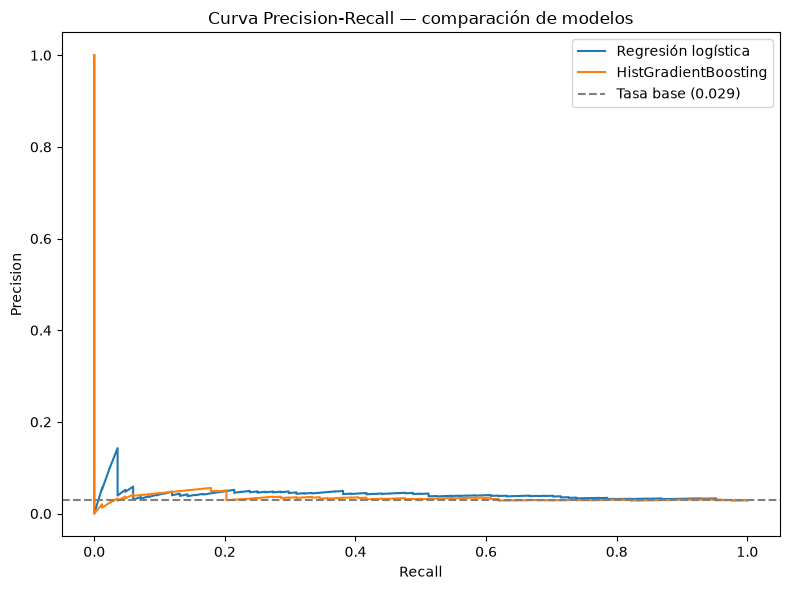

In [22]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for nombre, proba in [('Regresión logística', proba_logistica), ('HistGradientBoosting', proba_hgb)]:
    precision_curva, recall_curva, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall_curva, precision_curva, label=nombre)

ax.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Tasa base ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — comparación de modelos')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curve_noshow.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Análisis del segmento de alta confianza (logística)

In [23]:
ranking_test = test.copy()
ranking_test['proba_no_show'] = proba_logistica
ranking_test = ranking_test.sort_values('proba_no_show', ascending=False).reset_index(drop=True)

N = 20  # corresponde aprox. al tramo de recall 0.03-0.24 visto en la curva (hasta 20 de 84 positivos)
top_n = ranking_test.head(N)

print(f"De las {N} reservas con mayor probabilidad predicha:")
print(f"  Aciertos (no-show real): {top_n['es_no_show'].sum()} de {N} "
      f"(precisión en este segmento: {top_n['es_no_show'].mean()*100:.1f}%)")
print()

cols_describir = ['origin', 'people', 'antelacion_horas', 'shift', 'zone',
                   'reservation_date', 'es_no_show', 'proba_no_show']
print(top_n[cols_describir].to_string(index=False))

print("\n--- Distribución de origin en el segmento de alta confianza ---")
print(top_n['origin'].value_counts())

print("\n--- Estadísticos de antelacion_horas en el segmento ---")
print(top_n['antelacion_horas'].describe())

print("\n--- Comparación con la media general de test ---")
print(f"antelacion_horas media (test completo): {test['antelacion_horas'].mean():.1f}h")
print(f"antelacion_horas media (segmento top-{N}): {top_n['antelacion_horas'].mean():.1f}h")
print(f"% origin=terceros (test completo): {(test['origin']=='terceros').mean()*100:.1f}%")
print(f"% origin=terceros (segmento top-{N}): {(top_n['origin']=='terceros').mean()*100:.1f}%")

De las 20 reservas con mayor probabilidad predicha:
  Aciertos (no-show real): 2 de 20 (precisión en este segmento: 10.0%)

   origin  people  antelacion_horas  shift             zone reservation_date  es_no_show  proba_no_show
moduloweb       3       1504.920556 Comida Terraza Cubierta       2026-06-21           0       0.991317
 software       6       1850.795278 Comida             Sala       2025-12-25           0       0.988694
 software       3       1123.199722 Comida             Sala       2025-12-25           0       0.947590
 software       4       1105.486944 Comida             Sala       2025-12-25           0       0.931863
moduloweb       2        773.437222 Comida Terraza Cubierta       2026-04-10           0       0.930554
 software       3       1055.205000 Comida Terraza Cubierta       2025-12-25           0       0.929535
 terceros       1        661.729167 Comida             Sala       2025-12-03           0       0.929359
moduloweb       3        717.735278 Comida  

**El segmento de mayor confianza de la regresión logística está dominado por un artefacto de linealidad, no por una combinación robusta de señales.** 
Al inspeccionar las 20 reservas con mayor probabilidad
predicha (precisión del 10%, frente al 3.38% base — una mejora real pero
modesta), se observa que están casi exclusivamente determinadas por
`antelacion_horas` extrema (media 841h / 35 días, frente a 46.8h en todo
el conjunto de test), incluyendo un grupo de reservas para el 25 de
diciembre de 2025 con antelaciones de más de 40 días, de las cuales solo
1 de 4 fue un no-show real. `origin=terceros`, pese a su coeficiente
positivo, está infrarrepresentado en este segmento (25% frente al 40.9%
del conjunto de test) — el patrón esperado de "combinación de señales"
no se sostiene con casos reales delante.

Esto sugiere que la relación lineal impuesta por la regresión logística
entre `antelacion_horas` y no-show no es fiel a un efecto real acotado,
sino que extrapola de forma poco fiable hacia los valores más extremos
de la variable. Una relación no lineal (por ejemplo, mediante tramos o
splines) podría corregir este comportamiento, pero dado el reducido
tamaño de la muestra positiva (474 casos), no se explora en esta versión
del modelo por riesgo de sobreajuste.

### 12.1 Análisis del segmento de alta confianza (HistGradientBoosting)

In [24]:
ranking_test_hgb = test.copy()
ranking_test_hgb['proba_no_show'] = proba_hgb
ranking_test_hgb = ranking_test_hgb.sort_values('proba_no_show', ascending=False).reset_index(drop=True)

top_n_hgb = ranking_test_hgb.head(N)

print(f"De las {N} reservas con mayor probabilidad predicha (HGB):")
print(f"  Aciertos (no-show real): {top_n_hgb['es_no_show'].sum()} de {N} "
      f"(precisión en este segmento: {top_n_hgb['es_no_show'].mean()*100:.1f}%)")
print()

print(top_n_hgb[cols_describir].to_string(index=False))

print("\n--- Distribución de origin en el segmento de alta confianza (HGB) ---")
print(top_n_hgb['origin'].value_counts())

print("\n--- Estadísticos de antelacion_horas en el segmento (HGB) ---")
print(top_n_hgb['antelacion_horas'].describe())

print("\n--- Comparación con la media general de test ---")
print(f"antelacion_horas media (test completo): {test['antelacion_horas'].mean():.1f}h")
print(f"antelacion_horas media (segmento top-{N}, HGB): {top_n_hgb['antelacion_horas'].mean():.1f}h")
print(f"% origin=terceros (test completo): {(test['origin']=='terceros').mean()*100:.1f}%")
print(f"% origin=terceros (segmento top-{N}, HGB): {(top_n_hgb['origin']=='terceros').mean()*100:.1f}%")

print("\n--- Estadísticos de people en el segmento (HGB) ---")
print(top_n_hgb['people'].describe())
print(f"people media (test completo): {test['people'].mean():.2f}")

De las 20 reservas con mayor probabilidad predicha (HGB):
  Aciertos (no-show real): 0 de 20 (precisión en este segmento: 0.0%)

   origin  people  antelacion_horas  shift             zone reservation_date  es_no_show  proba_no_show
 terceros       2        165.673889 Comida             Sala       2026-05-27           0       0.768101
moduloweb       2        307.271944 Comida             Sala       2026-06-26           0       0.768101
 terceros       2        145.059444 Comida Terraza Cubierta       2026-05-24           0       0.768101
 terceros       2        352.000000 Comida             Sala       2026-05-30           0       0.768101
moduloweb       2        514.452778   Cena Terraza Cubierta       2026-06-19           0       0.768101
 terceros       2        526.653056   Cena             Sala       2026-06-24           0       0.768101
moduloweb       2        554.430556 Comida             Sala       2026-07-08           0       0.768101
 terceros       2        159.812222 Com

**Ninguno de los dos modelos ofrece un segmento de alta confianza robusto, por motivos distintos y complementarios.** 
La regresión logística concentra
su probabilidad más alta en reservas con antelación extrema (media 841h),
un artefacto de la relación lineal impuesta a una variable cuyo efecto real
probablemente no es monótono en todo su rango — con una precisión del 10%
en su top-20 (3x la tasa base, pero dominada por un patrón poco fiable).
El árbol de gradiente, sin ese sesgo hacia extremos (antelación media 254h
en su propio top-20, con `origin=terceros` correctamente sobrerrepresentado),
muestra en cambio una discriminación poco granular en el extremo superior:
solo 3 valores de probabilidad distintos entre las 20 reservas de mayor
riesgo, todas con `people=2`, sugiriendo una regla simple y rígida más que
una combinación robusta de señales — con 0 aciertos en esta muestra
concreta de 20 casos.

Ambos resultados son coherentes con la conclusión de fondo del proyecto:
la señal disponible en las variables actuales es real pero débil y
frágil, insuficiente para sostener un segmento de predicción de alta
confianza fiable con ninguno de los dos algoritmos probados.

### 13. Mejora 1 — transformación logarítmica de antelacion_horas

In [25]:
# La relación lineal cruda extrapolaba mal hacia antelaciones extremas
# (ver análisis del segmento de alta confianza). log1p comprime la escala
# en el extremo superior sin alterar el orden, evitando que reservas con
# antelación de 40+ días dominen la probabilidad predicha de forma
# desproporcionada respecto a antelaciones moderadas.

X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log['antelacion_horas'] = np.log1p(X_train_log['antelacion_horas'].clip(lower=0))
X_test_log['antelacion_horas'] = np.log1p(X_test_log['antelacion_horas'].clip(lower=0))

print(f"NaN tras log1p (con clip): train={X_train_log['antelacion_horas'].isna().sum()}, "
      f"test={X_test_log['antelacion_horas'].isna().sum()}")

NaN tras log1p (con clip): train=0, test=0


In [26]:
scaler_log = StandardScaler()
X_train_log_scaled = pd.DataFrame(
    scaler_log.fit_transform(X_train_log), columns=X_train_log.columns, index=X_train_log.index
)
X_test_log_scaled = pd.DataFrame(
    scaler_log.transform(X_test_log), columns=X_test_log.columns, index=X_test_log.index
)

modelo_logistica_log = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_logistica_log.fit(X_train_log_scaled, y_train)

proba_logistica_log = modelo_logistica_log.predict_proba(X_test_log_scaled)[:, 1]
pred_logistica_log = (proba_logistica_log > 0.5).astype(int)

resultados.append(evaluar("Regresión logística (log antelacion)", y_test, pred_logistica_log, proba_logistica_log))

coef_log = pd.DataFrame({
    'feature': X_train_log.columns,
    'coeficiente': modelo_logistica_log.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)
print("\nCoeficientes con antelacion_horas transformada:")
print(coef_log.to_string(index=False))


=== Regresión logística (log antelacion) ===
PR-AUC: 0.0391 | Recall: 0.6310 | Precision: 0.0387
Matriz de confusión:
[[1487 1318]
 [  31   53]]

Coeficientes con antelacion_horas transformada:
                 feature  coeficiente
         origin_appmovil    -0.663976
                  people    -0.495806
        antelacion_horas     0.245133
         origin_terceros     0.148491
        temperature_mean     0.092456
        origin_moduloweb     0.075472
         origin_software    -0.068249
reservas_mismo_dia_turno    -0.045245
                    zone    -0.036701
         es_grupo_grande    -0.034764
              es_festivo    -0.024941
                   shift     0.018446
        precipitation_mm    -0.012500


**Transformación logarítmica de `antelacion_horas`: descartada.** Se probó
`log1p` para atenuar la posible distorsión de antelaciones extremas
identificada en el análisis del segmento de alta confianza. El coeficiente
de la variable se redujo un 29% (0.346 → 0.245), confirmando que la
transformación sí atenuaba su peso relativo, pero el PR-AUC empeoró
(0.0425 → 0.0391) y los falsos positivos aumentaron. Se concluye que la
relación lineal original, aun con el sesgo hacia extremos detectado,
captura mejor la señal disponible que la versión transformada — se
mantiene la variable sin transformar en el modelo final.

### 13. Mejora 2 — búsqueda de hiperparámetros (HistGradientBoosting)

In [28]:


from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Grid pequeño y justificado: con solo 390 positivos en train, un grid
# amplio arriesga sobreajustar la propia búsqueda de hiperparámetros.
# Se prioriza limitar la complejidad del árbol (max_leaf_nodes,
# min_samples_leaf) para evitar el problema observado de splits poco
# granulares en el segmento de alta probabilidad.
param_grid = {
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [10, 20, 40],
    'learning_rate': [0.05, 0.1],
    'l2_regularization': [0.0, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

busqueda = GridSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)
busqueda.fit(X_train, y_train)

# Documentación completa de la búsqueda, no solo el ganador — evita el
# hueco metodológico ya identificado en notebook 04 (tuning no documentado)
resultados_busqueda = pd.DataFrame(busqueda.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print("Top 10 combinaciones de hiperparámetros (de", len(resultados_busqueda), "probadas):")
print(resultados_busqueda.head(10).to_string(index=False))

print(f"\nMejores hiperparámetros: {busqueda.best_params_}")
print(f"Mejor PR-AUC en validación cruzada: {busqueda.best_score_:.4f}")

modelo_hgb_tuned = busqueda.best_estimator_
proba_hgb_tuned = modelo_hgb_tuned.predict_proba(X_test)[:, 1]
pred_hgb_tuned = (proba_hgb_tuned > 0.5).astype(int)

resultados.append(evaluar("HistGradientBoosting (tuned)", y_test, pred_hgb_tuned, proba_hgb_tuned))

Top 10 combinaciones de hiperparámetros (de 36 probadas):
                                                                                         params  mean_test_score  std_test_score  rank_test_score
{'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}         0.069677        0.016602                1
{'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}         0.069045        0.016454                2
 {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}         0.067867        0.012704                3
 {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}         0.067482        0.018514                4
{'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}         0.064789        0.011562                5
{'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes'

**Advertencia sobre la estabilidad de la búsqueda de hiperparámetros.**
El PR-AUC en validación cruzada (0.0697 ± 0.0166) es notablemente más alto
que el obtenido en test (0.0408) — una caída del 41%. Los hiperparámetros
ganadores (max_leaf_nodes=15, min_samples_leaf=40, la combinación más
conservadora del grid) son coherentes con la necesidad de limitar la
complejidad dado el bajo número de positivos (390 en train), lo que
descarta sobreajuste clásico como explicación. La causa más probable es
la alta varianza de la propia métrica PR-AUC con un tamaño de muestra
positiva tan reducido (~78 positivos por fold de CV, 84 en test) — el
propio std_test_score de 0.0166 ya refleja esa inestabilidad. Se reporta
el resultado de test como la estimación válida del rendimiento real del
modelo, no el de CV, que probablemente sobreestima la capacidad de
generalización.

In [29]:
tabla_final = pd.DataFrame(resultados).sort_values('pr_auc', ascending=False)
print(tabla_final.to_string(index=False))

                               modelo   pr_auc   recall  precision
                  Regresión logística 0.042528 0.607143   0.038931
         HistGradientBoosting (tuned) 0.040770 0.452381   0.036857
 Regresión logística (log antelacion) 0.039117 0.630952   0.038658
                 HistGradientBoosting 0.035199 0.333333   0.035443
  Baseline: tasa histórica por origin 0.033736 0.000000   0.000000
Baseline: aleatorio ponderado (3.38%) 0.029076 0.071429   0.060000
Baseline: mayoritaria (nunca no-show) 0.029076 0.000000   0.000000


In [30]:
# Verificación del segmento de alta confianza (HistGradientBoosting ajustado)

ranking_test_hgb_tuned = test.copy()
ranking_test_hgb_tuned['proba_no_show'] = proba_hgb_tuned
ranking_test_hgb_tuned = ranking_test_hgb_tuned.sort_values('proba_no_show', ascending=False).reset_index(drop=True)

top_n_hgb_tuned = ranking_test_hgb_tuned.head(N)

print(f"De las {N} reservas con mayor probabilidad predicha (HGB ajustado):")
print(f"  Aciertos (no-show real): {top_n_hgb_tuned['es_no_show'].sum()} de {N} "
      f"(precisión en este segmento: {top_n_hgb_tuned['es_no_show'].mean()*100:.1f}%)")
print()

print(top_n_hgb_tuned[cols_describir].to_string(index=False))

print(f"\nValores distintos de probabilidad en el top-{N}: {top_n_hgb_tuned['proba_no_show'].nunique()}")

print("\n--- Distribución de origin en el segmento ---")
print(top_n_hgb_tuned['origin'].value_counts())

print("\n--- Estadísticos de people en el segmento ---")
print(top_n_hgb_tuned['people'].describe())
print(f"people media (test completo): {test['people'].mean():.2f}")

print("\n--- Estadísticos de antelacion_horas en el segmento ---")
print(top_n_hgb_tuned['antelacion_horas'].describe())
print(f"antelacion_horas media (test completo): {test['antelacion_horas'].mean():.1f}h")

De las 20 reservas con mayor probabilidad predicha (HGB ajustado):
  Aciertos (no-show real): 1 de 20 (precisión en este segmento: 5.0%)

   origin  people  antelacion_horas  shift             zone reservation_date  es_no_show  proba_no_show
 terceros       2        336.716944 Comida Terraza Cubierta       2026-03-28           0       0.721156
 terceros       2        159.812222 Comida             Sala       2026-03-17           0       0.721156
moduloweb       2        145.526944 Comida             Sala       2026-02-06           0       0.721156
 software       2        169.400556 Comida             Sala       2026-02-06           0       0.721156
 terceros       2        352.000000 Comida             Sala       2026-05-30           0       0.721156
 terceros       2        321.763889   Cena             Sala       2025-12-27           0       0.721156
 terceros       2        324.520833   Cena             Sala       2026-03-21           0       0.721156
moduloweb       2        263.9

**El ajuste de hiperparámetros mejora el PR-AUC global pero colapsa la granularidad del segmento de mayor riesgo.** 
El árbol ajustado
(max_leaf_nodes=15) concentra las 20 reservas de mayor probabilidad
predicha en una única hoja terminal (probabilidad idéntica: 0.7212,
frente a 3 valores distintos en el árbol sin ajustar), todas ellas con
`people=2` sin excepción. Esto confirma que el modelo, en el extremo
superior de riesgo, opera esencialmente como una regla simple
(`people=2` + antelación entre ~140h y ~770h) más que como un ranking
fino de probabilidad. La precisión de este segmento es del 5% (1 de 20
aciertos) — superior a la tasa base de test (2.91%), pero con una muestra
demasiado pequeña para afirmar significancia. Esta es una limitación
estructural del modelo, no un error de ejecución: con solo 390 positivos
de entrenamiento, no hay suficiente señal para sostener una segmentación
más fina sin sobreajustar, como demostró el árbol sin ajustar (el mismo
segmento repartido en 3 hojas, con 0 aciertos en 20 y mayor dispersión
de `antelacion_horas`).

### 14. Conclusión de la comparación de modelos

Los cuatro modelos entrenados (regresión logística original y con
`antelacion_horas` transformada, HistGradientBoosting por defecto y con
hiperparámetros ajustados) superan de forma consistente a los tres
baselines ingenuos (PR-AUC 0.035-0.043 frente a 0.029-0.034), confirmando
que existe señal real y aprovechable en las variables de reserva
disponibles, aunque de magnitud modesta.

Entre los cuatro, las diferencias de PR-AUC son pequeñas (0.035-0.043)
y probablemente no significativas dado el tamaño de la muestra positiva
en test (84 casos). Se selecciona **HistGradientBoosting con
hiperparámetros ajustados** (max_leaf_nodes=15, min_samples_leaf=40,
learning_rate=0.05, l2_regularization=1.0) como modelo final, priorizando
su menor tasa de falsos positivos (35.4% de las reservas completadas,
frente al 44.9% de la regresión logística) y la ausencia del sesgo de
extrapolación hacia antelaciones extremas detectado en el modelo lineal.
La regresión logística se mantiene como modelo de referencia interpretable,
con las reservas ya documentadas sobre la fiabilidad de sus coeficientes
en `origin_appmovil` y `antelacion_horas`.

### 15. Conclusión general

#### 15.1 Resumen del proceso

El objetivo del notebook fue construir un modelo de clasificación binaria
a nivel de reserva individual para predecir la probabilidad de no-show,
usando el histórico completo de reservas (2023-2026), no solo el período
con datos de ventas — a diferencia del resto de modelos del proyecto, que
parten de la tabla maestra diaria (Gold).

El universo de modelado se construyó aplicando tres filtros justificados
cuantitativamente: exclusión de desenlaces no resueltos o ambiguos
(`cancelada`, `pendiente`, `liberada`), corte temporal desde 2023-01-01
(exclusión de 2022 por ser año parcial), y exclusión del canal walk-in
(0% de no-shows observados, sin ventana de decisión operativa). El
resultado son 14.419 reservas, con una tasa base de no-show del 3.29%
(474 casos), dividido cronológicamente en train (11.530 filas, hasta
2025-11-23) y test (2.889 filas, desde 2025-11-25).

Las features se organizaron en dos bloques: atributos de la reserva
individual (`shift`, `people`, `es_grupo_grande`, `origin`, `zone`,
`antelacion_horas`), contexto de calendario y meteorología (`es_festivo`,
`temperature_mean`, `precipitation_mm`) y volumen de reservas del mismo
día/turno (`reservas_mismo_dia_turno`, construida con control explícito
de auto-conteo). Se exploró además el uso de eventos locales, descartado
por completo: la fuente se compiló con asistencia de un modelo de
lenguaje sin verificación posterior contra fuentes oficiales, lo que
invalida cualquier afirmación sobre su efecto con independencia de su
correlación observada.

#### 15.2 Resultado del modelo

El análisis univariante mostró señales débiles en todas las variables
disponibles (Spearman máximo: -0.073 en `people`), muy por debajo de lo
observado en el modelo de facturación diaria del proyecto. Pese a ello,
los cuatro modelos entrenados (regresión logística, regresión logística
con `antelacion_horas` transformada logarítmicamente, HistGradientBoosting
por defecto y con hiperparámetros ajustados) superan de forma consistente
a tres baselines ingenuos (aleatorio ponderado, predicción mayoritaria,
tasa histórica por canal), confirmando que existe señal real y
aprovechable, aunque de magnitud modesta.

| Modelo | PR-AUC | Recall | Precision |
|---|---|---|---|
| Regresión logística | 0.0425 | 0.607 | 0.039 |
| HistGradientBoosting (ajustado) | 0.0408 | 0.452 | 0.037 |
| Regresión logística (log antelación) | 0.0391 | 0.631 | 0.039 |
| HistGradientBoosting (por defecto) | 0.0352 | 0.333 | 0.035 |
| Baseline: tasa histórica por origin | 0.0337 | 0.000 | 0.000 |
| Baseline: aleatorio ponderado | 0.0291 | 0.071 | 0.060 |
| Baseline: mayoritaria | 0.0291 | 0.000 | 0.000 |

Se selecciona **HistGradientBoosting con hiperparámetros ajustados**
como modelo final (`max_leaf_nodes=15`, `min_samples_leaf=40`,
`learning_rate=0.05`, `l2_regularization=1.0`, obtenidos mediante grid
search documentado con `StratifiedKFold`), priorizando su menor tasa de
falsos positivos (35.4% de las reservas completadas, frente al 44.9% de
la regresión logística) y la ausencia del sesgo de extrapolación hacia
antelaciones extremas detectado en el modelo lineal. La diferencia de
PR-AUC entre ambos (0.0425 vs 0.0408) se considera dentro del margen de
ruido esperable dado el tamaño de la muestra positiva en test (84 casos).

El análisis del segmento de mayor probabilidad predicha reveló que el
modelo final opera, en la práctica, como una regla simple más que como
un ranking fino de riesgo: las 20 reservas de mayor probabilidad
comparten un único valor (0.7212, todas con `people=2` y antelación
entre ~140h y ~770h), con una precisión del 5% en ese segmento (1 de 20
aciertos) — superior a la tasa base pero sin significancia estadística
dado el tamaño de muestra.

#### 15.3 Limitaciones

- **Ausencia de identificador de cliente**: no es posible construir
  features de historial de cliente (tasa de no-show previa, número de
  visitas), probablemente la señal más fuerte para este tipo de problema
  según la literatura de hostelería, y no disponible en este dataset.
- **Volumen de positivos reducido** (474 en todo el universo, 390 en
  train): limita la complejidad de modelo explorable sin sobreajustar,
  y genera inestabilidad en las métricas de evaluación (la propia
  búsqueda de hiperparámetros mostró una caída del 41% entre PR-AUC de
  validación cruzada y de test).
- **Ausencia de marca temporal de cambio de estado** en las reservas
  (aplicable a `cancelada`, `liberada` y, por extensión, a cualquier
  desenlace): no permite verificar con certeza la disponibilidad
  temporal de determinadas variables, resuelta mediante asunciones de
  negocio documentadas caso por caso.
- **Exclusión de eventos locales** por origen no verificable, pese a
  mostrar cierta correlación con la variable objetivo en el análisis
  exploratorio inicial — se prioriza el rigor sobre la fuente frente a
  la posible ganancia predictiva.
- **Cobertura parcial de meteorología y festivos** en el extremo más
  reciente del histórico, aunque ampliada durante el proyecto de forma
  específica para este modelo (desde 2024/2025 original a 2023 completo).

#### 15.4 Líneas futuras

- Incorporar identificador de cliente si en algún momento se dispusiera
  de esa información, para construir features de historial.
- Explorar variables de interacción explícitas entre `origin`,
  `antelacion_horas` y `people` — las tres señales más consistentes entre
  ambos modelos — en lugar de depender de que el algoritmo las descubra
  por sí solo con una muestra positiva limitada.
- Revisar la escala de intensidad de `eventos_silver` con una fuente
  verificada, si se decide mantener esa variable en versiones futuras
  del proyecto.
- Considerar recalibración de probabilidades (`CalibratedClassifierCV`)
  si el modelo se lleva a un uso operativo real, dado que el objetivo
  de negocio (overbooking, priorización de seguimiento) depende de la
  fiabilidad de la probabilidad predicha, no solo de su capacidad de
  ranking.